# HITL 실습
```mermaid
flowchart TD
    START([START])
    FETCH["1. 주문 정보 등록 및 금액 생성<br/>fetch_payment_data"]
    ROUTER1{"금액 조건 확인<br/>check_amount_policy"}
    HR["2. 담당자 승인 대기<br/>human_review<br/>(⚠️ interrupt_before 중단 지점)"]
    ROUTER2{"승인 여부 확인<br/>check_human_approval"}
    PAY["3. 최종 결제 처리<br/>execute_payment"]
    CANCEL["3. 결제 취소 처리<br/>cancel_payment"]
    END([END])

    START --> FETCH
    FETCH --> ROUTER1

    ROUTER1 -->|">= 50,000원 (고액)"| HR
    ROUTER1 -->|"< 50,000원 (일반)"| PAY

    HR --> ROUTER2
    ROUTER2 -->|"승인 (approved=True)"| PAY
    ROUTER2 -->|"거절/미승인 (approved=False)"| CANCEL

    PAY --> END
    CANCEL --> END
```


In [1]:
import random
from typing import TypedDict, Literal
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import InMemorySaver

In [2]:
class PaymentState(TypedDict):
    amount: int      # 금액
    status: str      # 상태
    approved: bool   # 승인여부

## Nodes

In [3]:
def fetch_payment_node(state: PaymentState):
    """API 대신 random으로 1만원~10만원 사이의 금액을 생성합니다."""
    # 10,000원 ~ 100,000원 사이 1만원 단위 생성
    random_amount = random.randint(1, 10) * 10000  
    print(f"[1. 결제 요청] 금액: {random_amount:,}원")
    return {"amount": random_amount, "status": "created", "approved": False}

In [ ]:
from langgraph.types import interrupt

def human_review_node(state: PaymentState):
    """
    [작성 조건]
    1. `interrupt()` 함수를 호출하여 실행을 일시 중지하고, 외부(사용자)로 메시지를 전달.
    2. 외부에서 Command(resume=...)로 넘겨준 값(예: 'y' 또는 'n')을 response 변수에 저장.
    3. 받아온 값이 'y'이면 approved를 True로, 'n'이면 False로 하여 State를 업데이트.
    """
    print(f"\n[⚠️ 고액 결제 알림] {state['amount']:,}원 결제 - 사람 승인 필요")    

    # HITL 에 들어간 Human 에게 넘겨줄 데이터
    response = interrupt({
        'question': f'[2. 승인] {state['amount']} 원 결제를 승인하시겠습니까?',
        'amount': state['amount'],
        'status': state['status'],
    })

    # 사용자의 'decision' 이 'y' 면 state['approved'] 를 True 로.
    # if response['decision'] == 'y':
    #     return {'approved': True}
    # else:
    #     return {'approved': False}


    # Human의 결정을 어떻게 받아서 처리할 것인가
    return {'approved': response['decision'] == 'y'}   
    

In [19]:
def execute_payment_node(state: PaymentState):
    print(f"\n[3. 결제 완료] {state['amount']:,}원 최종 결제가 완료되었습니다!")
    return {"status": "completed"}

In [20]:
def cancel_payment_node(state: PaymentState):
    print(f"\n[3. 결제 취소] 담당자 승인 거절로 인해 {state['amount']:,}원 결제가 취소되었습니다.")
    return {"status": "cancelled"}

## Routers

In [21]:
def check_amount_policy_router(state: PaymentState):
    if state["amount"] >= 50000:
        return "human_review"
    else:
        return "execute_payment"

In [22]:
def check_human_approval_router(state: PaymentState) -> Literal["execute_payment", "cancel_payment"]:
    # 승인 하면 결제
    if state.get("approved", False):
        return "execute_payment"
    # 승인 안하거나 state 에 'approved' 키 없으면 취소
    else:
        return "cancel_payment"

## Build

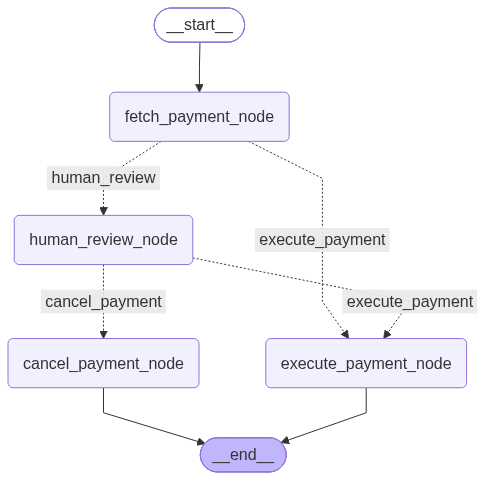

In [23]:
builder = StateGraph(PaymentState)

builder.add_node("fetch_payment_node", fetch_payment_node)
builder.add_node("human_review_node", human_review_node)
builder.add_node("execute_payment_node", execute_payment_node)
builder.add_node("cancel_payment_node", cancel_payment_node)

builder.add_edge(START, "fetch_payment_node")

builder.add_conditional_edges(
    "fetch_payment_node", 
    check_amount_policy_router, 
    {
        "human_review": "human_review_node",
        "execute_payment": "execute_payment_node"
    }
)

builder.add_conditional_edges(
    "human_review_node", 
    check_human_approval_router,
    {
        "execute_payment": "execute_payment_node",
        "cancel_payment": "cancel_payment_node"
    }
)

builder.add_edge("execute_payment_node", END)
builder.add_edge("cancel_payment_node", END)

graph = builder.compile(checkpointer=InMemorySaver())
graph

In [32]:
from langgraph.types import Command


config = {"configurable": {"thread_id": '1234'}}

# 1. 그래프 실행
res = graph.invoke({}, config)

# HITL 실행
if res.get('__interrupt__'):
    # interrupt()에서 던진 값 확인
    interrupt_value = res['__interrupt__']
    print(f"\n[전달받은 중단 정보]: {interrupt_value}")
    
    # 사용자 입력을 가정하여 Command(resume=...)로 재개
    user_decision = Command(
        resume={'decision': 'y'}  # 'y', 'n' 중에 결정
    )
    
    # 💡 Command(resume=값)을 전달하여 interrupt() 지점부터 다시 진행
    graph.invoke(user_decision, config)

[1. 결제 요청] 금액: 100,000원

[⚠️ 고액 결제 알림] 100,000원 결제 - 사람 승인 필요

[전달받은 중단 정보]: [Interrupt(value={'question': '[2. 승인] 100000 원 결제를 승인하시겠습니까?', 'amount': 100000, 'status': 'created'}, id='51c93c22e5e4b9bfcb9aaae04705aaee')]

[⚠️ 고액 결제 알림] 100,000원 결제 - 사람 승인 필요

[3. 결제 완료] 100,000원 최종 결제가 완료되었습니다!
